# Santiago Marin yepes

Voy a centrarme en la parte interna sin tener encuenta la frontera

In [ ]:
import numpy as np
from scipy.integrate import quad
import matplotlib.pyplot as plt

def phi_i(i, x, a, b, N): #Funcion del mapeo
    h = (b - a)/(N-1)
    xi = a + i*h
    if i == 0:
        if a <= x <= a + h:
            return (a + h - x)/h
        return 0.0

    elif i == N-1:
        if b - h <= x <= b:
            return (x - (b - h))/h
        return 0.0

    elif (xi-h <= x) & (x <= xi):
        return (x - (xi-h))/h

    elif (xi <= x) & (x <= xi+h):
        return (xi+h - x)/h
    return 0.0

def dev_phi_i(i, x, a, b, N): # Derivada del mapeo
    h = (b - a)/(N-1)
    xi = a + i*h
    if i == 0:
        if a < x < a+h:
            return -1/h
        return 0.0

    elif i == N-1:
        if b-h < x < b:
            return 1/h
        return 0.0

    elif (xi-h < x) & (x < xi):
        return 1/h
    elif (xi < x) & (x < xi+h):
        return -1/h
    return 0.0

def integrand1(x, j, i, a, b, N):# Función para la integración del mapeo
    return dev_phi_i(j, x, a, b, N) * dev_phi_i(i, x, a, b, N)
def f(x):
  return x*np.exp(x)
def integrand2(x,f, i, a, b, Ua, Ub, N):# Función para la integración del lado derecho de la ecuación
    return f(x) * phi_i(i, x, a, b, N)-Ua*dev_phi_i(i, x, a, b, N)*dev_phi_i(0, x, a, b, N)-Ub*dev_phi_i(i, x, a, b, N)*dev_phi_i(N-1, x, a, b, N)

def A_ij(f,i, j, a, b, N): # Elemento ij de la matrix A
    h = (b - a)/(N-1)
    xi = a + i*h

    I1, _ = quad(f, xi-h, xi, args=(j,i,a,b,N))
    I2, _ = quad(f, xi, xi+h, args=(j,i,a,b,N))

    return I1 + I2

def b_i(i, a, b, Ua, Ub, N,g):# Elemento i del vector b
    h = (b - a)/(N-1)
    xi = a + i*h

    I1, _ = quad(integrand2, xi-h, xi, args=(g,i,a,b,Ua,Ub,N))
    I2, _ = quad(integrand2, xi, xi+h, args=(g,i,a,b,Ua,Ub,N))

    return I1 + I2

In [ ]:
def A_matrix(a, b, N):
    index = range(1, N-1)
    return np.array([[A_ij(integrand1,i, j, a, b, N) for j in index] for i in index])

def b_vector(a, b, Ua, Ub, N,g):
    index = range(1, N-1)
    return np.array([b_i(i, a, b,Ua, Ub, N,g) for i in index])

def U(x, c, a, b, N):# Función que construye el vector de coeficientes de la solución
    return sum(c[i] * phi_i(i, x, a, b, N) for i in range(N))

In [ ]:
Ua=3- np.e
Ub=0
N=20
a=0
b=1

In [ ]:
def y_exact(x):
    return np.exp(x)*(2-x) - x + 1 - np.e

def solucion(a,b,Ua,Ub,N,g):
  """
    Calcula la solución numérica de un problema de valor en la frontera
    mediante el método de elementos finitos en 1D.

    Parámetros
    ----------
    a : float
        Límite inferior del intervalo.
    b : float
        Límite superior del intervalo.
    Ua : float
        Condición de frontera en x = a.
    Ub : float
        Condición de frontera en x = b.
    N : int
        Número de elementos finitos (nodos).
    g : function
        Función del lado derecho de la ecuación diferencial.

    Retorna
    -------
    c : ndarray
        Vector de tamaño N que contiene la solución numérica en los nodos. Para -Y''=g(x)

    Además
    -------
    Genera la gráfica de la solución numérica.
 """
  A  = A_matrix(a, b, N)
  B = b_vector(a, b, Ua, Ub, N, g )
  h = (b - a)/(N-1)
  c_int = np.linalg.solve(A, B)

  c = np.zeros(N)
  c[0] = Ua
  c[-1] = Ub
  c[1:-1] = c_int
  x = np.linspace(a,b , N)
  plt.plot(np.linspace(a, b, N), np.array([U(x, c, a, b, N) for x in np.linspace(a, b, N)]), '.',label='sol numerica')
  return c

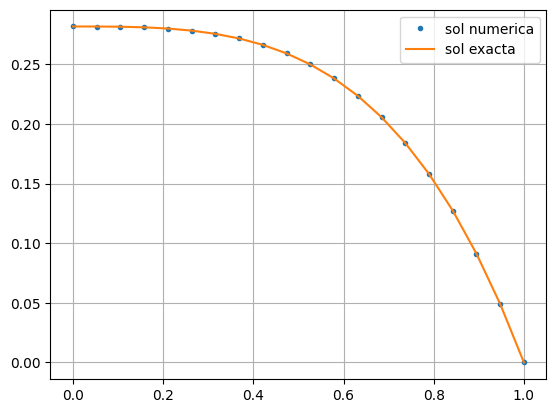

In [ ]:
c=solucion(0,1,Ua,Ub,N,f)
plt.plot(np.linspace(0,1,N), y_exact(np.linspace(0,1,N)), '-', label='sol exacta')
plt.legend()
plt.grid()
plt.show()

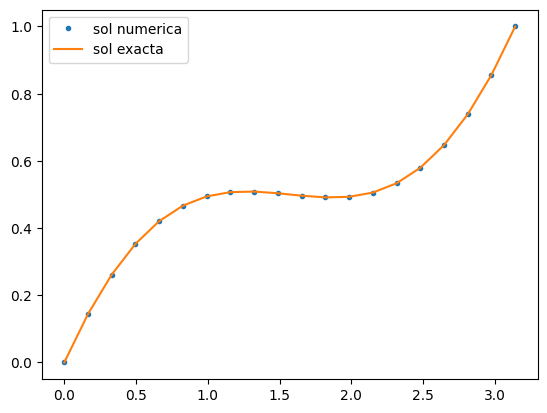

In [ ]:
def h(x):
  return np.cos(x)
def sol2(x):
  return -1+np.cos(x)+(3*x)/np.pi
c1= solucion(0,np.pi,0,1,N,h) #La funcion solucion grafica la solucion numerica de la ecuacion -Y''=f(x), usando elementos finitos
plt.plot(np.linspace(0,np.pi,N),sol2(np.linspace(0,np.pi,N)),'-',label='sol exacta')
plt.legend()

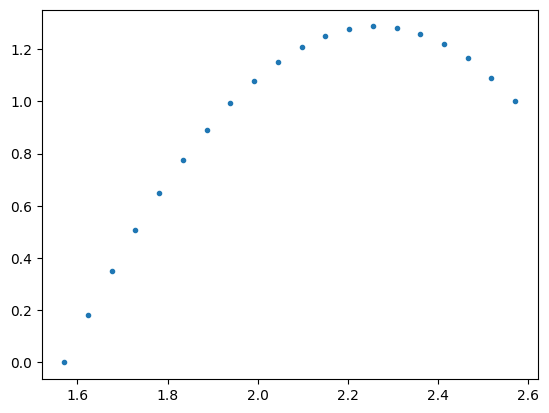

In [ ]:
def P(x):
  return np.exp(x)*(x**-1)+np.sin(x)+np.log(x)
c2= solucion(np.pi/2,np.pi/2+1,0,1,N,P)

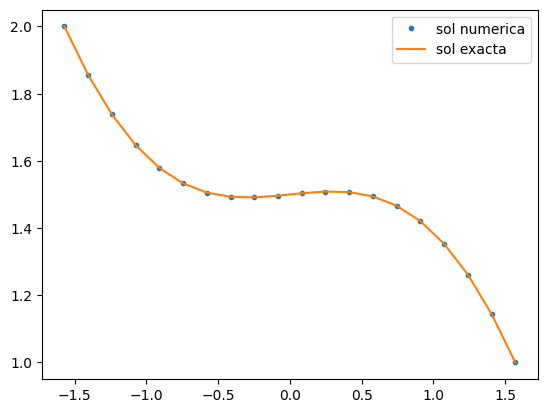

In [ ]:
def K(x):
  return np.sin(x)
def sol3(x):
  return np.sin(x)-(3*x)/np.pi+3/2
c2= solucion(-np.pi/2,np.pi/2,2,1,N,K)
plt.plot(np.linspace(-np.pi/2,np.pi/2,N),sol3(np.linspace(-np.pi/2,np.pi/2,N)),'-',label='sol exacta')
plt.legend()

... subir el .ipynb

usa integracion cuadratica??? no el codigo de clase
No esta bien el punto b)

NOta 4